# Workshop - Clustering Project
- Complete items 1 - 4 and submit into CANVAS.
- Item 5 is optional.

## 1. Data Prep
You need to complete the following:
1. Read in the data file: wholesale_clients.csv
2. Remove the unused columns
3. standardize the data

In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [4]:
# 1. Read in the data file wholesale_clients.csv
data_path = "wholesale_clients.csv"  # load dataset
df = pd.read_csv(data_path)

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
# 2. Remove the Channel (restaurant, hotel, etc.) and Region columns since they are not fields we want to model on

newdf = df.drop(columns=["Channel", "Region"])

In [6]:
# 3. Standardize the data
newdf_scaled = StandardScaler().fit_transform(newdf)

## 2. Compare Different Clustering Techniques
For each of the following FOUR models, fit the model on the scaled data, note down the number of data points in each cluster and record the silhouette score:
1. K-Means with 3 clusters
2. K-Means with 5 clusters
3. Hierarchical Clustering with 5 clusters
4. DBSCAN with esp = 3.5, min_samples = 2 clusters

### 2.1. K-Means Clustering with 3 clusters


In [14]:

kmeans3 = KMeans(n_clusters=3, random_state=42)
kmeans3.fit(newdf_scaled)
#kmeans3.labels_

sil_score = silhouette_score(newdf_scaled, kmeans3.labels_)
print("Silhouette score:", sil_score)


Silhouette score: 0.4582633767207058


### 2.2. K-Means Clustering with 5 clusters



In [15]:
kmeans5 = KMeans(n_clusters=5, random_state=42)
kmeans5.fit(newdf_scaled)
#kmeans3.labels_

sil_score = silhouette_score(newdf_scaled, kmeans5.labels_)
print("Silhouette score:", sil_score)

Silhouette score: 0.36890127429678043


### 2.3. Hierarchical Clustering with 5 clusters


In [16]:
from sklearn.cluster import AgglomerativeClustering


agg = AgglomerativeClustering(n_clusters = 5, linkage ="ward")
hier_cluster_labels = agg.fit_predict(newdf_scaled)

#kmeans3.labels_

sil_score = silhouette_score(newdf_scaled, hier_cluster_labels)
print("Silhouette score:", sil_score)

Silhouette score: 0.23988371669170097


### 2.4. DBSCAN with esp = 3.5, min_samples = 2 clusters

In [28]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=3.5, min_samples=2)
dbscan_labels = dbscan.fit_predict(newdf_scaled)
#kmeans3.labels_

sil_score = silhouette_score(newdf_scaled, dbscan_labels, metric='euclidean', sample_size=None)
print("Silhouette score:", sil_score)

Silhouette score: 0.740283564230615


## 3. Recommend Client Segments
Based on the comparison, select the best model, and review the results with the best model:
1. Choose the best model
2. Plot the graph of the cluster centers
3. Name the clusters
4. Clearly state what you would recommend as client segments and how you would better support those clients


In [23]:
# use the defined print_metrics function to print the results for the FOUR models
from collections import Counter


def print_metrics(model, data):
    print(model)
    print(Counter(model.labels_))
    print(silhouette_score(data, model.labels_))

In [26]:
print_metrics(kmeans3, newdf_scaled)
print_metrics(kmeans5, newdf_scaled)
print_metrics(agg, newdf_scaled)
print_metrics(dbscan, newdf_scaled)

KMeans(n_clusters=3, random_state=42)
Counter({np.int32(0): 350, np.int32(1): 53, np.int32(2): 37})
0.4582633767207058
KMeans(n_clusters=5, random_state=42)
Counter({np.int32(3): 272, np.int32(0): 96, np.int32(1): 59, np.int32(2): 11, np.int32(4): 2})
0.36890127429678043
AgglomerativeClustering(n_clusters=5)
Counter({np.int64(4): 177, np.int64(0): 153, np.int64(2): 104, np.int64(1): 5, np.int64(3): 1})
0.23988371669170097
DBSCAN(eps=3.5, min_samples=2)
Counter({np.int64(0): 430, np.int64(-1): 8, np.int64(1): 2})
0.740283564230615


In [29]:
dbscan_labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

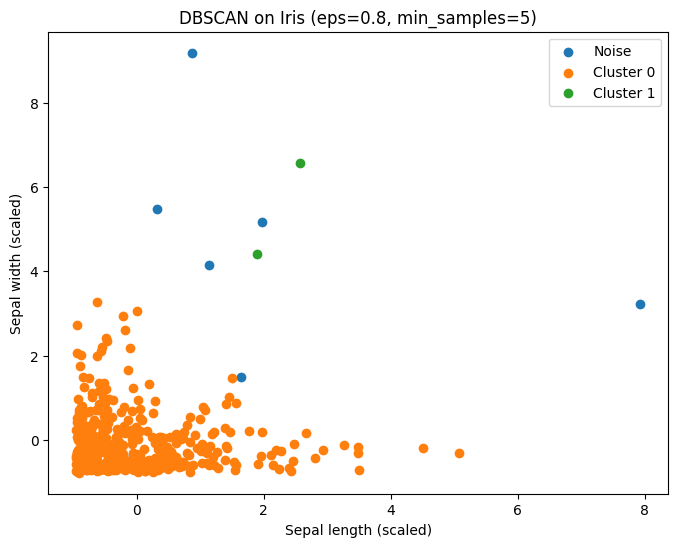

In [27]:
plt.figure(figsize=(8,6))

unique_labels = np.unique(dbscan_labels)

for label in unique_labels:
    cluster_name = 'Noise' if label == -1 else f'Cluster {label}'
    
    plt.scatter(
        newdf_scaled[dbscan_labels == label, 0], # , 0 -> first feature-> sepal length
        newdf_scaled[dbscan_labels == label, 1], # , 1-> second feature -> sepal width
        label=cluster_name
    )

plt.xlabel("Sepal length (scaled)")
plt.ylabel("Sepal width (scaled)")
plt.title("DBSCAN on Iris (eps=3.5, min_samples=2)")
plt.legend()
plt.show()

## 4. Predict the Cluster of a New Client using KMeans predict

In [ ]:
# 1. Given this new client, determine which cluster they fall into
new_client = pd.DataFrame([np.array([20000, 20000, 25000, 600, 20000, 1000])], columns=data.columns)
new_client

In [ ]:
# 2. Scale the new client data using the same scaler object from the Data Prep step
new_client_scaled = pd.DataFrame(scaler.transform(new_client), columns=data.columns)
new_client_scaled

In [ ]:
# 3. Make a prediction using the K-Means model with 3 clusters


In [ ]:
# 4. Which cluster does the new client belong to? Cluster 2, buying a lot of grocery and detergents / paper items

## 5. (Optional) This session is optional, it is not mandatory for submission.
- Tune the parameter for K-Means:
1. Write a loop to fit models with 2-15 clusters for KMeans
2. Plot Elbow method 
3. Identify the elbow of the plot and fit a KMeans model just for that number of clusters
4. Find the number of clients in each cluster
5. Create a heat map of the cluster centers
6. create a silhouette scores plot instead of an inertia plot
- Tune DBSCAN
1. write a tune_dbscan function to loop through of the combinations of eps and min_samples
2. apply the dune_dbscan function on the scaled data
3. sort the results by highest silhouette score

End of Workshop.